# 使用自動微分估算簡單線性迴歸的參數(w、b)
## $ y = wx + b$

In [1]:
# 載入套件
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.linear_model import LinearRegression

## 定義訓練函數

In [2]:
def train(
    X: torch.Tensor,
    y: torch.Tensor,
    epochs: int = 100,
    lr: float = 0.0_001,
):
    loss_list: list[float] = []
    w_list: list[float] = []
    b_list: list[float] = []

    # w、b 初始值均設為常態分配之隨機亂數
    w = torch.randn(1, requires_grad=True, dtype=torch.float)
    b = torch.randn(1, requires_grad=True, dtype=torch.float)
    for epoch in range(epochs):  # 執行訓練週期
        y_pred = w * X + b  # 預測值

        # 計算損失函數值
        # MSE = torch.square(y - y_pred).mean()
        # MSE = (y - y_pred).square().mean()
        MSE = ((y - y_pred) ** 2).mean()
        MSE.backward()

        # 設定不參與梯度下降，w、b才能運算
        with torch.no_grad():
            # 新權重 = 原權重 — 學習率(learning_rate) * 梯度(gradient)
            assert w.grad is not None
            assert b.grad is not None
            w -= lr * w.grad
            b -= lr * b.grad

        # 記錄訓練結果
        if (epoch + 1) % 1000 == 0 or epochs < 1000:
            # detach：與運算圖分離，numpy()：轉成陣列
            # w.detach().numpy()
            w_list.append(w.item())  # w.item()：轉成常數
            b_list.append(b.item())
            loss_list.append(MSE.item())

        # 梯度重置
        assert w.grad is not None
        assert b.grad is not None
        w.grad.zero_()
        b.grad.zero_()

    return w_list, b_list, loss_list

## 產生隨機資料

In [3]:
# 產生線性隨機資料100筆，介於 0-50
n = 100
X = np.linspace(0, 50, n)
y = np.linspace(0, 50, n)

# 資料加一點雜訊(noise)
X += np.random.uniform(-10, 10, n)
y += np.random.uniform(-10, 10, n)

## 執行訓練

In [4]:
# 執行訓練
w_list, b_list, loss_list = train(torch.tensor(X), torch.tensor(y))

# 取得 w、b 的最佳解
print(f'w={w_list[-1]}, b={b_list[-1]}')

w=0.8893803954124451, b=0.9333897233009338


In [5]:
# 執行訓練
w_list, b_list, loss_list = train(torch.tensor(X), torch.tensor(y), epochs=100_000)

# 取得 w、b 的最佳解
print(f'w={w_list[-1]}, b={b_list[-1]}')

w=0.8465710878372192, b=2.44561505317688


## 以NumPy驗證

In [6]:
# 執行訓練
coef = np.polyfit(X, y, deg=1)

# 取得 w、b 的最佳解
print(f'w={coef[0]}, b={coef[1]}')

w=0.8459653053476625, b=2.467013430865054


In [7]:
X2 = X.reshape(X.shape[0], 1)

lr = LinearRegression()
lr.fit(X2, y)

lr.coef_[0], lr.intercept_

(np.float64(0.8459653053476619), np.float64(2.467013430865048))

## 顯示迴歸線

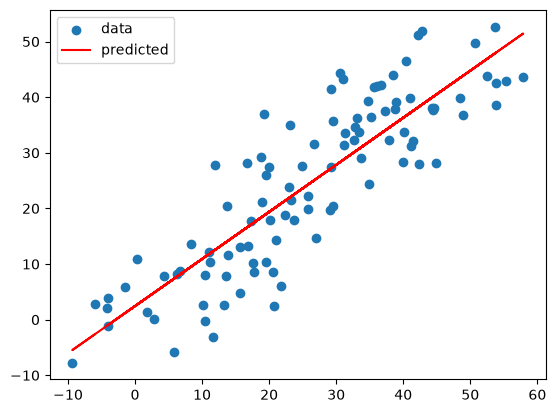

In [8]:
plt.scatter(X, y, label='data')
plt.plot(X, w_list[-1] * X + b_list[-1], 'r-', label='predicted')
plt.legend()

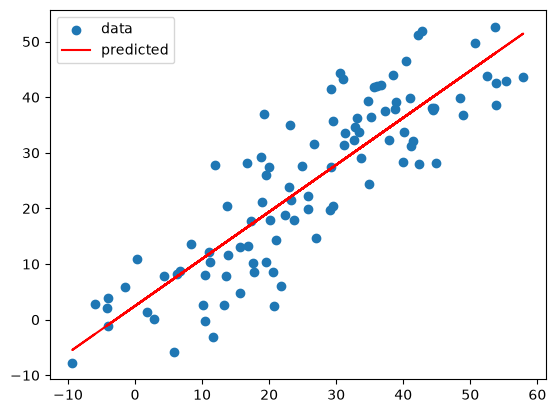

In [9]:
# NumPy 求得的迴歸線
plt.scatter(X, y, label='data')
plt.plot(X, coef[0] * X + coef[1], 'r-', label='predicted')
plt.legend()

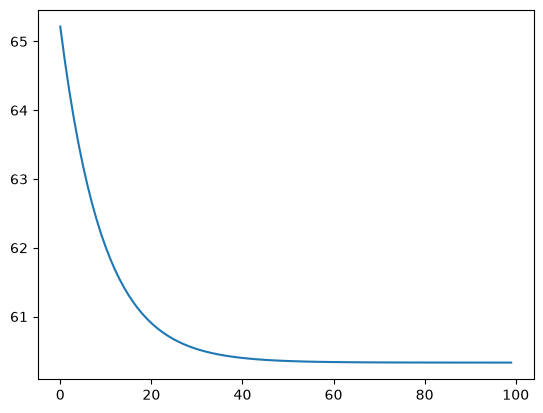

In [10]:
# 損失函數繪圖
plt.plot(loss_list)

In [11]:
loss_list

[65.21573111744443,
 64.7198371842474,
 64.27428663364209,
 63.87396526600434,
 63.514282389616234,
 63.19111297634381,
 62.90075018729983,
 62.639862876396556,
 62.40546035855226,
 62.194852965804486,
 62.00562543239178,
 61.8356073542318,
 61.68284868438228,
 61.54559737541218,
 61.422278740369094,
 61.31147915530295,
 61.211927482695884,
 61.12248152065094,
 61.04211578890685,
 60.96990831912493,
 60.90503096932585,
 60.84673989676913,
 60.79436591094227,
 60.747309202283994,
 60.705029286666495,
 60.66704132612118,
 60.63290975312134,
 60.60224278940282,
 60.57468889326557,
 60.54993268263759,
 60.527689369754334,
 60.50770393064797,
 60.489747310145376,
 60.47361360075367,
 60.45911779012551,
 60.44609321224307,
 60.43439132698124,
 60.42387707702068,
 60.41443033808638,
 60.40594244453723,
 60.3983160637913,
 60.3914640966457,
 60.38530756373953,
 60.379776534819214,
 60.374806606301625,
 60.370340971659445,
 60.36632886324283,
 60.36272319694436,
 60.35948456176357,
 60.35657481

In [12]:
w_list

[0.966859757900238,
 0.9605593681335449,
 0.9545871615409851,
 0.9489262700080872,
 0.9435603618621826,
 0.9384742975234985,
 0.9336529970169067,
 0.9290831089019775,
 0.924751341342926,
 0.920645534992218,
 0.9167534112930298,
 0.9130643606185913,
 0.9095674753189087,
 0.9062528014183044,
 0.9031108617782593,
 0.9001325964927673,
 0.8973097801208496,
 0.8946337699890137,
 0.8920974731445312,
 0.8896933197975159,
 0.8874143958091736,
 0.8852542638778687,
 0.8832066655158997,
 0.8812657594680786,
 0.8794262409210205,
 0.8776822686195374,
 0.8760294914245605,
 0.8744624853134155,
 0.8729774355888367,
 0.8715697526931763,
 0.8702352046966553,
 0.8689703941345215,
 0.8677714467048645,
 0.8666350245475769,
 0.8655577898025513,
 0.864536702632904,
 0.8635688424110413,
 0.8626515865325928,
 0.8617819547653198,
 0.8609576225280762,
 0.860176146030426,
 0.8594357371330261,
 0.8587336540222168,
 0.8580681681632996,
 0.8574375510215759,
 0.8568395376205444,
 0.8562729358673096,
 0.855735480785369

In [13]:
b_list

[-1.8035290241241455,
 -1.5809664726257324,
 -1.3700042963027954,
 -1.1700360774993896,
 -0.980489194393158,
 -0.8008208274841309,
 -0.6305159330368042,
 -0.4690861999988556,
 -0.31606996059417725,
 -0.1710280478000641,
 -0.033545129001140594,
 0.09677278995513916,
 0.2202991098165512,
 0.33738774061203003,
 0.44837456941604614,
 0.5535769462585449,
 0.6532965898513794,
 0.7478195428848267,
 0.8374162316322327,
 0.9223436713218689,
 1.002845048904419,
 1.0791507959365845,
 1.1514803171157837,
 1.2200394868850708,
 1.285025954246521,
 1.3466256856918335,
 1.4050151109695435,
 1.4603619575500488,
 1.512824535369873,
 1.5625519752502441,
 1.6096882820129395,
 1.6543684005737305,
 1.696720004081726,
 1.7368643283843994,
 1.7749162912368774,
 1.810986042022705,
 1.8451744318008423,
 1.87758207321167,
 1.9083001613616943,
 1.9374178647994995,
 1.9650185108184814,
 1.9911800622940063,
 2.0159785747528076,
 2.039482593536377,
 2.061763286590576,
 2.082883834838867,
 2.102902889251709,
 2.12188